## Datasets
1. **BLS Average Price** — monthly prices for selected goods (`Dataset #2 - inflation.txt`)
2. **BLS Employment, Hours & Earnings** — monthly employment series by industry (`Dataset #1 - earnings.txt`)
3. **Zillow Observed Rent Index** — monthly rent index by metro (`Dataset #3 - Metro_zori_uc_sfrcondomfr_sm_month.csv`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Inflation (BLS Average Price)

In [2]:
# build a code -> item-name lookup from the ids file
labels = {}
with open('inflation_ids.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        label, code = line.rsplit(' - ', 1)
        labels[code.strip()] = label.strip()
len(labels)

15

In [3]:
# load prices, tidy the id column, attach item names
df = pd.read_csv('Dataset #2 - inflation.txt')
df = df.rename(columns={'Series ID': 'series_id'})
df['item'] = df['series_id'].map(labels)
df[['series_id', 'item']]

,series_id,item
0,APU0000704111,"Bacon, sliced, per lb."
1,APU0000711211,"Bananas, per lb."
2,APU0000702111,"Bread, white, pan, per lb."
3,APU0000706111,"Chicken, fresh, whole, per lb."
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb."
5,APU0000708111,"Eggs, grade A, large, per doz."
6,APU0000701111,"Flour, white, all purpose, per lb."
7,APU0000709112,"Milk, fresh, whole, fortified, per gal."
8,APU0000711311,"Oranges, navel, per lb."
9,APU0000701312,"Rice, white, long grain, uncooked, per lb."


In [4]:
# reshape wide -> long: one row per item-month
inf_long = df.melt(id_vars=['series_id', 'item'], var_name='month', value_name='price')
inf_long.head()

,series_id,item,month,price
0,APU0000704111,"Bacon, sliced, per lb.",Jan 2016,5.656
1,APU0000711211,"Bananas, per lb.",Jan 2016,0.581
2,APU0000702111,"Bread, white, pan, per lb.",Jan 2016,1.425
3,APU0000706111,"Chicken, fresh, whole, per lb.",Jan 2016,1.429
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",Jan 2016,4.498


In [5]:
# parse month strings to dates; force prices numeric (placeholders/blanks -> NaN)
inf_long['month'] = pd.to_datetime(inf_long['month'], format='%b %Y', errors='coerce')
inf_long['price'] = pd.to_numeric(inf_long['price'], errors='coerce')
inf_long.head()

,series_id,item,month,price
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656
1,APU0000711211,"Bananas, per lb.",2016-01-01,0.581
2,APU0000702111,"Bread, white, pan, per lb.",2016-01-01,1.425
3,APU0000706111,"Chicken, fresh, whole, per lb.",2016-01-01,1.429
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",2016-01-01,4.498


In [6]:
# drop rows with no date or price, then report coverage
inf_long = inf_long.dropna(subset=['month', 'price'])
print('rows:', len(inf_long))
print('date range:', inf_long['month'].min().date(), '->', inf_long['month'].max().date())
inf_long.head()

rows: 1814
date range: 2016-01-01 -> 2026-04-01


,series_id,item,month,price
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656
1,APU0000711211,"Bananas, per lb.",2016-01-01,0.581
2,APU0000702111,"Bread, white, pan, per lb.",2016-01-01,1.425
3,APU0000706111,"Chicken, fresh, whole, per lb.",2016-01-01,1.429
4,APU0000717311,"Coffee, 100%, ground roast, all sizes, per lb.",2016-01-01,4.498


In [7]:
# monthly observations per item (some items have shorter histories)
inf_long.groupby('item').size().sort_values()

item
Coffee, 100%, ground roast, all sizes, per lb.    108
Oranges, navel, per lb.                           111
Tomatoes, field grown, per lb.                    121
Chicken, fresh, whole, per lb.                    122
Flour, white, all purpose, per lb.                122
Rice, white, long grain, uncooked, per lb.        122
Bacon, sliced, per lb.                            123
Bananas, per lb.                                  123
Bread, white, pan, per lb.                        123
Eggs, grade A, large, per doz.                    123
Electricity per KWH                               123
Fuel oil #2 per gallon                            123
Gasoline, all types, per gallon                   123
Milk, fresh, whole, fortified, per gal.           123
Gasoline, unleaded regular, per gallon            124
dtype: int64

In [8]:
# grab each item's first (Jan 2016) price as its baseline
base = inf_long.sort_values('month').groupby('item').first()['price'].rename('base')
base

item
Bacon, sliced, per lb.                            5.656
Bananas, per lb.                                  0.581
Bread, white, pan, per lb.                        1.425
Chicken, fresh, whole, per lb.                    1.429
Coffee, 100%, ground roast, all sizes, per lb.    4.498
Eggs, grade A, large, per doz.                    2.328
Electricity per KWH                               0.134
Flour, white, all purpose, per lb.                0.522
Fuel oil #2 per gallon                            1.970
Gasoline, all types, per gallon                   2.034
Gasoline, unleaded regular, per gallon            1.967
Milk, fresh, whole, fortified, per gal.           3.313
Oranges, navel, per lb.                           1.196
Rice, white, long grain, uncooked, per lb.        0.709
Tomatoes, field grown, per lb.                    2.528
Name: base, dtype: float64

In [9]:
# index every month to that baseline (Jan 2016 = 100) so items share one scale
inf_idx = inf_long.join(base, on='item')
inf_idx['index_100'] = 100 * inf_idx['price'] / inf_idx['base']
inf_idx[inf_idx['series_id'] == 'APU0000704111'].head()

,series_id,item,month,price,base,index_100
0,APU0000704111,"Bacon, sliced, per lb.",2016-01-01,5.656,5.656,100.000000
15,APU0000704111,"Bacon, sliced, per lb.",2016-02-01,5.394,5.656,95.367751
30,APU0000704111,"Bacon, sliced, per lb.",2016-03-01,5.494,5.656,97.135785
45,APU0000704111,"Bacon, sliced, per lb.",2016-04-01,5.613,5.656,99.239745
60,APU0000704111,"Bacon, sliced, per lb.",2016-05-01,5.552,5.656,98.161245


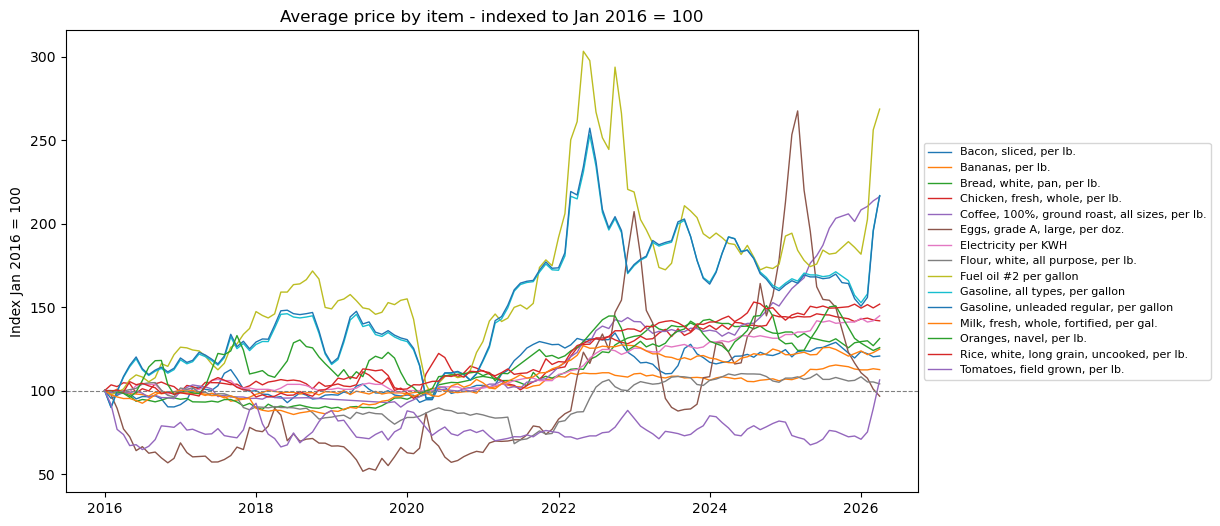

In [10]:
# plot every item's indexed price on one axis
fig, ax = plt.subplots(figsize=(11, 6))
for item, grp in inf_idx.groupby('item'):
    ax.plot(grp['month'], grp['index_100'], label=item, linewidth=1)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Average price by item - indexed to Jan 2016 = 100')
ax.set_ylabel('Index Jan 2016 = 100')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.show()

## Earnings BLS CES

Numbers are in thousands. Series prefixed `CEU` = not seasonally adjusted, `CES` = seasonally adjusted. The first two rows are total nonfarm

In [11]:
# load the earnings table and tidy the id column
earn = pd.read_csv('Dataset #1 - earnings.txt')
earn = earn.rename(columns={'Series ID': 'series_id'})
earn.shape

(348, 133)

In [12]:
# peek at a few series IDs (CEU = not adjusted, CES = seasonally adjusted)
earn['series_id'].head(10).tolist()

['CEU0000000001',
 'CES0000000001',
 'CEU0500000001',
 'CES0500000001',
 'CEU0600000001',
 'CES0600000001',
 'CEU1000000001',
 'CES1000000001',
 'CEU1011330001',
 'CES1011330001']

In [13]:
# reshape wide -> long: one row per series-month
earn_long = earn.melt(id_vars=['series_id'], var_name='month', value_name='employment')
earn_long.head()

,series_id,month,employment
0,CEU0000000001,Jan 2016,141073.0
1,CES0000000001,Jan 2016,143210.0
2,CEU0500000001,Jan 2016,119093.0
3,CES0500000001,Jan 2016,121096.0
4,CEU0600000001,Jan 2016,19238.0


In [14]:
# parse the month strings into real dates
earn_long['month'] = pd.to_datetime(earn_long['month'], format='%b %Y', errors='coerce')
earn_long.head()

,series_id,month,employment
0,CEU0000000001,2016-01-01,141073.0
1,CES0000000001,2016-01-01,143210.0
2,CEU0500000001,2016-01-01,119093.0
3,CES0500000001,2016-01-01,121096.0
4,CEU0600000001,2016-01-01,19238.0


In [15]:
# strip the '(P)' preliminary tag and force employment numeric (blanks/future months -> NaN)
earn_long['employment'] = pd.to_numeric(
    earn_long['employment'].astype(str).str.replace(r'\(P\)', '', regex=True).str.strip(),
    errors='coerce')
earn_long.head()

,series_id,month,employment
0,CEU0000000001,2016-01-01,141073.0
1,CES0000000001,2016-01-01,143210.0
2,CEU0500000001,2016-01-01,119093.0
3,CES0500000001,2016-01-01,121096.0
4,CEU0600000001,2016-01-01,19238.0


In [16]:
# drop empty rows and flag seasonally-adjusted (CES) series
earn_long = earn_long.dropna(subset=['month', 'employment'])
earn_long['adjusted'] = earn_long['series_id'].str.startswith('CES')
earn_long.head()

,series_id,month,employment,adjusted
0,CEU0000000001,2016-01-01,141073.0,False
1,CES0000000001,2016-01-01,143210.0,True
2,CEU0500000001,2016-01-01,119093.0,False
3,CES0500000001,2016-01-01,121096.0,True
4,CEU0600000001,2016-01-01,19238.0,False


In [17]:
# inspect a single series: total nonfarm, not seasonally adjusted
earn_long[earn_long['series_id'] == 'CEU0000000001'].head()

,series_id,month,employment,adjusted
0,CEU0000000001,2016-01-01,141073.0,False
348,CEU0000000001,2016-02-01,141900.0,False
696,CEU0000000001,2016-03-01,142797.0,False
1044,CEU0000000001,2016-04-01,143892.0,False
1392,CEU0000000001,2016-05-01,144541.0,False


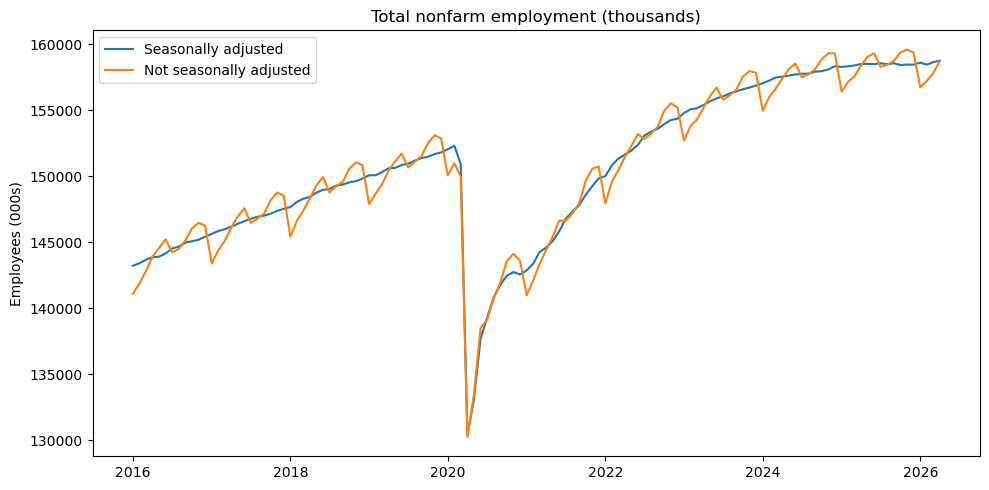

In [18]:
# total nonfarm employment, seasonally adjusted vs not
total = earn_long[earn_long['series_id'].isin(['CEU0000000001', 'CES0000000001'])]

fig, ax = plt.subplots(figsize=(10, 5))
for sid, grp in total.groupby('series_id'):
    label = 'Seasonally adjusted' if sid.startswith('CES') else 'Not seasonally adjusted'
    ax.plot(grp['month'], grp['employment'], label=label)
ax.set_title('Total nonfarm employment (thousands)')
ax.set_ylabel('Employees (000s)')
ax.legend()
fig.tight_layout()
plt.show()

## Rent (Zillow Observed Rent Index)

Monthly rent index by metro, plus a United States row. We'll use the US row as a headline trend.

In [19]:
# load the Zillow rent index and note the id columns
rent = pd.read_csv('Dataset #3 - Metro_zori_uc_sfrcondomfr_sm_month.csv')
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
print(rent.shape)
print('regions:', rent['RegionName'].nunique())
rent[id_cols].head()

(720, 141)
regions: 720


,RegionID,SizeRank,RegionName,RegionType,StateName
0,102001,0,United States,country,NaN
1,394913,1,"New York, NY",msa,NY
2,753899,2,"Los Angeles, CA",msa,CA
3,394463,3,"Chicago, IL",msa,IL
4,394514,4,"Dallas, TX",msa,TX


In [20]:
# reshape wide -> long: one row per region-month
rent_long = rent.melt(id_vars=id_cols, var_name='month', value_name='zori')
rent_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,month,zori
0,102001,0,United States,country,NaN,2015-01-31,1142.150088
1,394913,1,"New York, NY",msa,NY,2015-01-31,2208.053897
2,753899,2,"Los Angeles, CA",msa,CA,2015-01-31,1730.517939
3,394463,3,"Chicago, IL",msa,IL,2015-01-31,1387.825224
4,394514,4,"Dallas, TX",msa,TX,2015-01-31,1054.190026


In [21]:
# parse month dates and drop rows with no date or rent value
rent_long['month'] = pd.to_datetime(rent_long['month'], errors='coerce')
rent_long = rent_long.dropna(subset=['month', 'zori'])
rent_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,month,zori
0,102001,0,United States,country,NaN,2015-01-31,1142.150088
1,394913,1,"New York, NY",msa,NY,2015-01-31,2208.053897
2,753899,2,"Los Angeles, CA",msa,CA,2015-01-31,1730.517939
3,394463,3,"Chicago, IL",msa,IL,2015-01-31,1387.825224
4,394514,4,"Dallas, TX",msa,TX,2015-01-31,1054.190026


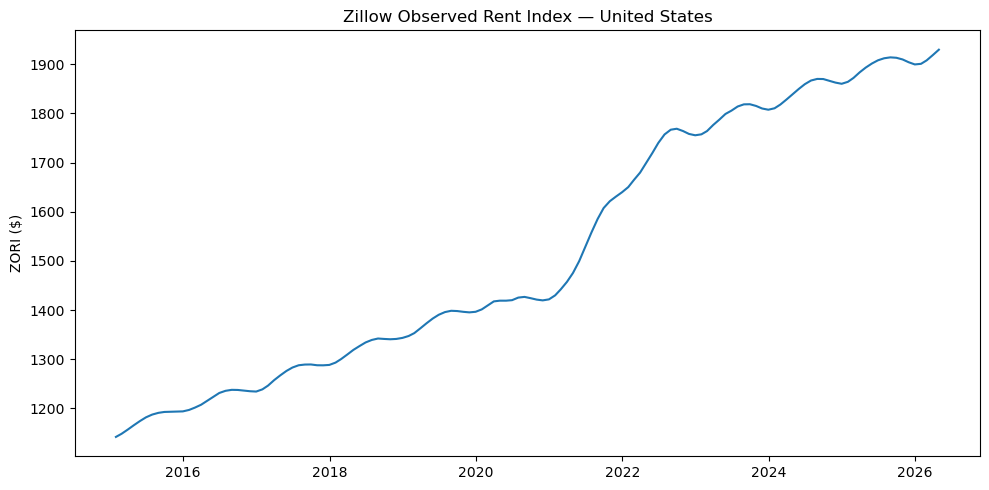

In [22]:
# plot the national (United States) rent trend
us = rent_long[rent_long['RegionName'] == 'United States']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(us['month'], us['zori'])
ax.set_title('Zillow Observed Rent Index — United States')
ax.set_ylabel('ZORI ($)')
fig.tight_layout()
plt.show()

## Quick overlay

All three series rebased to Jan 2016 = 100 so they can be compared on one axis.

In [23]:
# helper: rebase a series to 100 at its first value on/after `start`
def rebase(df, date_col, val_col, start='2016-01-01'):
    s = df.sort_values(date_col).set_index(date_col)[val_col]
    base = s.loc[s.index >= start].iloc[0]
    return 100 * s / base

In [24]:
# build one headline series from each dataset
avg_price = inf_long.groupby('month')['price'].mean().reset_index()
emp_sa = earn_long[earn_long['series_id'] == 'CES0000000001']
rent_us = rent_long[rent_long['RegionName'] == 'United States']
avg_price.head()

,month,price
0,2016-01-01,2.019333
1,2016-02-01,1.946133
2,2016-03-01,1.936267
3,2016-04-01,1.945333
4,2016-05-01,1.947333


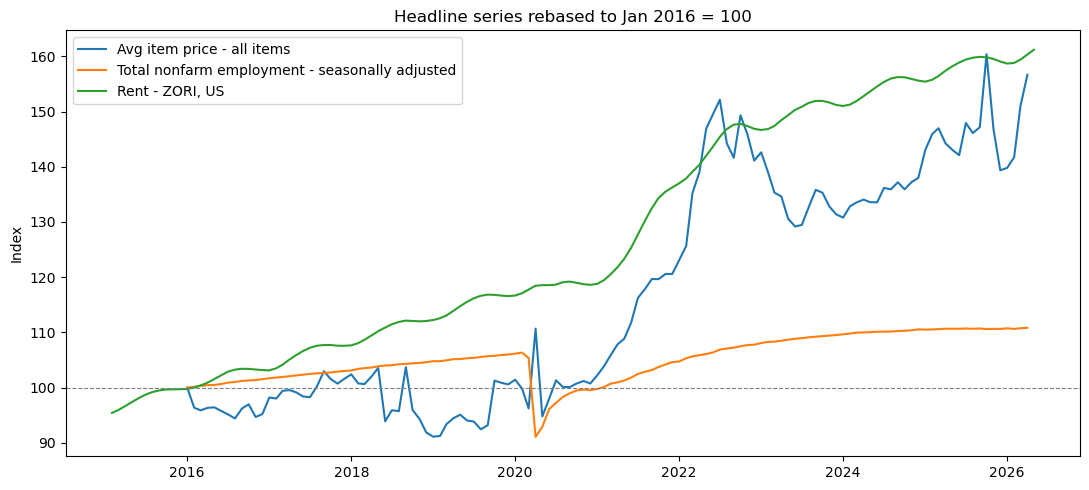

In [25]:
# overlay all three, rebased to Jan 2016 = 100
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rebase(avg_price, 'month', 'price'), label='Avg item price - all items')
ax.plot(rebase(emp_sa, 'month', 'employment'), label='Total nonfarm employment - seasonally adjusted')
ax.plot(rebase(rent_us, 'month', 'zori'), label='Rent - ZORI, US')
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Headline series rebased to Jan 2016 = 100')
ax.set_ylabel('Index')
ax.legend()
fig.tight_layout()
plt.show()